In [34]:
import mne

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from mne.preprocessing.nirs import (
    optical_density,
    temporal_derivative_distribution_repair,
)


#https://mne.tools/stable/auto_tutorials/preprocessing/70_fnirs_processing.html#sphx-glr-auto-tutorials-preprocessing-70-fnirs-processing-py im you want to look

In [12]:
with open("path.txt", "r") as f:
    path = Path(f.read().strip())

print(path)

C:\Users\sasha\Documents\GitHub\The-Effect-of-Surface-Awareness-on-Nausea-and-3D-Performance-\fnirsdata


In [14]:
# Path to a specific participant folder
# Specify the path to your NIRx data directory
fnirs_cw_amplitude_dir = path

# Load NIRx data
raw = mne.io.read_raw_nirx(fnirs_cw_amplitude_dir, verbose=True)
raw.load_data()

Loading C:\Users\sasha\Documents\GitHub\The-Effect-of-Surface-Awareness-on-Nausea-and-3D-Performance-\fnirsdata
Reading 0 ... 26197  =      0.000 ...  2575.270 secs...


C:\Users\sasha\AppData\Local\Temp\ipykernel_11276\1454542910.py:6: RuntimeWarning: MNE has not been tested with Aurora version 2023.9.3-1-g01ca56fc
  raw = mne.io.read_raw_nirx(fnirs_cw_amplitude_dir, verbose=True)


<RawNIRX | fnirsdata, 30 x 26198 (2575.4 s), ~6.0 MiB, data loaded>

In [15]:
raw.annotations.rename(
    {
        "2.0": "Scene",
        "3.0": "Scene",
        "4.0": "End_Game",
        "6.0": "Rest",
        "7.0": "Rest",
        "8.0": "Measurement",
        "9.0": "Measurement",
    }
)
raw.annotations.delete(raw.annotations.description == "End_Game")

#With actual data this needs to be changed (since it should have less tags)

In [16]:
#setting up sources

front_source = [1,2,3,4]
front_dectector = [1,2,3,4]

back_source = [5,6,7,8]
back_dectector = [5,6,7,8]

#Splitting channels into frontal and posterior regions based on source/detector numbers 

def get_region_channels(raw, sources, detectors):
    """Return channel names where both source AND detector are in the given sets."""
    matching = []
    for ch in raw.ch_names:
        # Channels names are S1_D1 etc
        parts = ch.split(" ")[0]  # strip hbo/hbr suffix
        if not (parts.startswith("S") and "_D" in parts):
            continue
        s_num = int(parts.split("_D")[0][1:])  # extract source number
        d_num = int(parts.split("_D")[1])       # extract detector number
        if s_num in sources and d_num in detectors:
            matching.append(ch)
    return matching

frontal_chs   = get_region_channels(raw, front_source, front_dectector)
posterior_chs = get_region_channels(raw, back_source, back_dectector)

raw_frontal   = raw.copy().pick(frontal_chs)
raw_posterior = raw.copy().pick(posterior_chs)

#Making sure things make sense

print(f"Frontal channels:   {len(frontal_chs)}")
print(f"Posterior channels: {len(posterior_chs)}")


print("Frontal channels:", frontal_chs)
print("Posterior channels:", posterior_chs)

Frontal channels:   14
Posterior channels: 16
Frontal channels: ['S1_D1 760', 'S1_D1 850', 'S1_D2 760', 'S1_D2 850', 'S1_D3 760', 'S1_D3 850', 'S2_D2 760', 'S2_D2 850', 'S3_D2 760', 'S3_D2 850', 'S4_D1 760', 'S4_D1 850', 'S4_D4 760', 'S4_D4 850']
Posterior channels: ['S5_D5 760', 'S5_D5 850', 'S6_D6 760', 'S6_D6 850', 'S6_D7 760', 'S6_D7 850', 'S6_D8 760', 'S6_D8 850', 'S7_D6 760', 'S7_D6 850', 'S7_D7 760', 'S7_D7 850', 'S8_D6 760', 'S8_D6 850', 'S8_D8 760', 'S8_D8 850']


In [17]:
def preprocess_region(raw_region, region_name):
    
    print(f"\n--- Processing {region_name} ---")

    # Convert to optical density
    raw_od = optical_density(raw_region)

    #Temporal Derivative Distribution Repair
    raw_od_tddr = temporal_derivative_distribution_repair(raw_od)

    # SCI
    sci = mne.preprocessing.nirs.scalp_coupling_index(raw_od_tddr)
    bad_chs = [
        raw_od_tddr.ch_names[i]
        for i, s in enumerate(sci)
        if s < 0.5
    ]
    if bad_chs:
        print(f"Bad channels (SCI < 0.5): {bad_chs}")
        raw_od_tddr.info["bads"] = bad_chs
    else:
        print(f"All channels passed SCI check.")

    raw_haemo = mne.preprocessing.nirs.beer_lambert_law(raw_od_tddr, ppf=0.1)

    print(f"Channels after processing: {raw_haemo.ch_names}")
    return raw_haemo

haemo_frontal   = preprocess_region(raw_frontal, "Frontal")
haemo_posterior = preprocess_region(raw_posterior, "Posterior")

def split_hbo_hbr(raw_haemo, region_name):
    hbo = raw_haemo.copy().pick(picks="hbo")
    hbr = raw_haemo.copy().pick(picks="hbr")
    print(f"{region_name} — HbO channels: {len(hbo.ch_names)}, "
          f"HbR channels: {len(hbr.ch_names)}")
    return hbo, hbr

frontal_hbo,   frontal_hbr   = split_hbo_hbr(haemo_frontal,   "Frontal")
posterior_hbo, posterior_hbr = split_hbo_hbr(haemo_posterior, "Posterior")


--- Processing Frontal ---
Bad channels (SCI < 0.5): ['S1_D1 760', 'S1_D1 850', 'S1_D3 760', 'S1_D3 850']
Channels after processing: ['S1_D1 hbo', 'S1_D1 hbr', 'S1_D2 hbo', 'S1_D2 hbr', 'S1_D3 hbo', 'S1_D3 hbr', 'S2_D2 hbo', 'S2_D2 hbr', 'S3_D2 hbo', 'S3_D2 hbr', 'S4_D1 hbo', 'S4_D1 hbr', 'S4_D4 hbo', 'S4_D4 hbr']

--- Processing Posterior ---
All channels passed SCI check.
Channels after processing: ['S5_D5 hbo', 'S5_D5 hbr', 'S6_D6 hbo', 'S6_D6 hbr', 'S6_D7 hbo', 'S6_D7 hbr', 'S6_D8 hbo', 'S6_D8 hbr', 'S7_D6 hbo', 'S7_D6 hbr', 'S7_D7 hbo', 'S7_D7 hbr', 'S8_D6 hbo', 'S8_D6 hbr', 'S8_D8 hbo', 'S8_D8 hbr']
Frontal — HbO channels: 7, HbR channels: 7
Posterior — HbO channels: 8, HbR channels: 8


In [ ]:
#Regions seperarted now need to process each region  
#think I need to use epochs for this https://mne.tools/stable/auto_tutorials/epochs/10_epochs_overview.html

#Build full epochs for each region and each tag then can split by time as needed later 

def get_epochs(raw_region, region_name):

    raw_copy = raw_region.copy()

    events, events_id = mne.events_from_annotations(raw_copy, event_id={"Scene": 1, "Rest": 2})

    epochs = mne.Epochs(raw_copy, events, event_id=events_id, tmin=5.0, tmax=30.0, baseline=None, preload=True, verbose=True)   

    print(f"{region_name} — Number of epochs: {len(epochs)}")
    return epochs 


epochs_frontal = get_epochs(haemo_frontal,   "Frontal")
epochs_posterior = get_epochs(haemo_posterior, "Posterior")




Used Annotations descriptions: [np.str_('Rest'), np.str_('Scene')]
Not setting metadata
98 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 98 events and 255 original time points ...
2 bad epochs dropped
Frontal — Number of epochs: 96
Used Annotations descriptions: [np.str_('Rest'), np.str_('Scene')]
Not setting metadata
98 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 98 events and 255 original time points ...
2 bad epochs dropped
Posterior — Number of epochs: 96



=== Frontal Validation ===
  Scene epochs: 48
  Rest epochs:  48
  Epoch duration: 24.97s
  Samples per epoch: 255

  Epoch onsets (Scene): [  27.0336     52.297728   84.443136  109.215744  128.483328  153.649152
  406.290432  431.652864  537.329664  567.21408   589.33248   618.82368
  793.509888  818.970624  860.848128  885.030912  904.593408  931.332096
 1104.052224 1128.431616 1150.1568   1175.420928 1196.35968  1222.90176
 1467.383808 1492.058112 1512.013824 1536.688128 1556.938752 1581.809664
 1759.838208 1785.593856 1801.617408 1827.766272 1845.755904 1870.528512
 2041.28256  2066.055168 2087.780352 2111.963136 2132.606976 2156.888064
 2331.967488 2357.035008 2378.170368 2402.648064 2421.22752  2446.29504 ]
  Epoch onsets (Rest):  [  10.81344    26.640384   66.3552     84.246528  112.656384  128.28672
  389.087232  406.093824  519.340032  537.23136   569.769984  589.234176
  776.994816  793.31328   845.512704  860.749824  888.17664   904.495104
 1085.472768 1103.855616 1132.3637

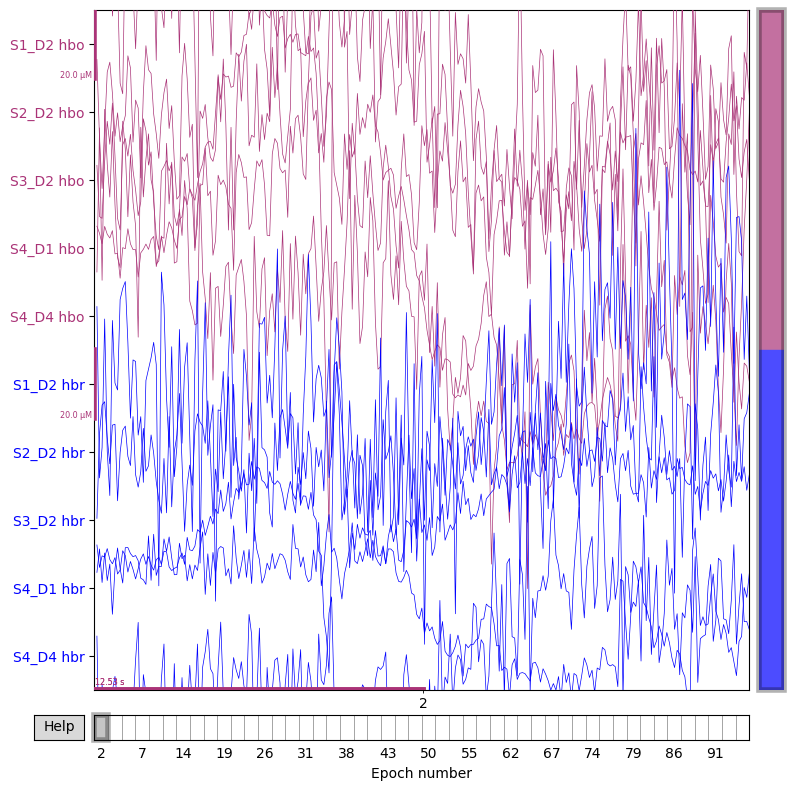

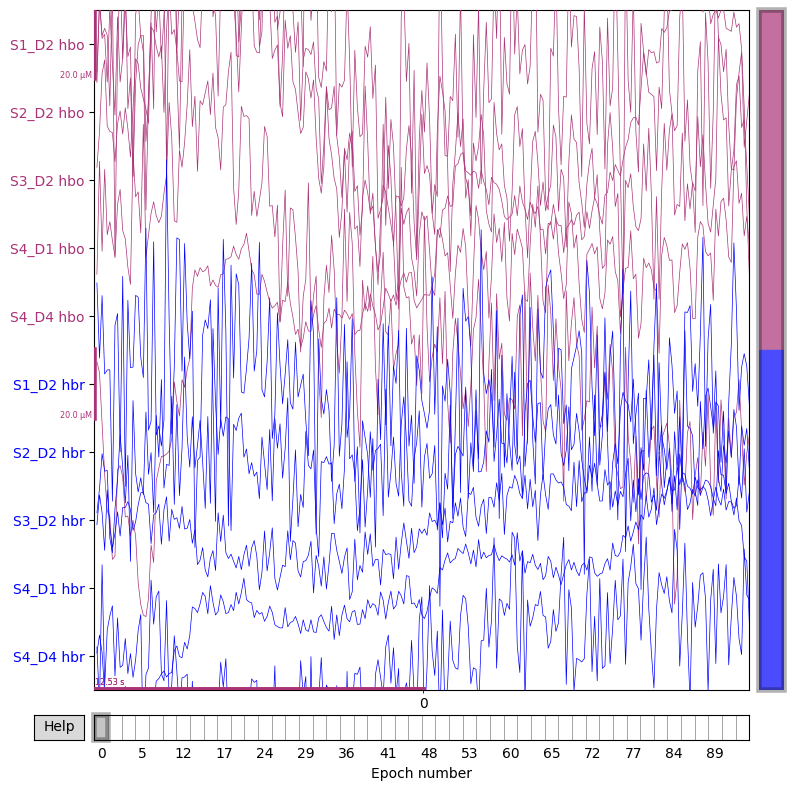


=== Posterior Validation ===
  Scene epochs: 48
  Rest epochs:  48
  Epoch duration: 24.97s
  Samples per epoch: 255

  Epoch onsets (Scene): [  27.0336     52.297728   84.443136  109.215744  128.483328  153.649152
  406.290432  431.652864  537.329664  567.21408   589.33248   618.82368
  793.509888  818.970624  860.848128  885.030912  904.593408  931.332096
 1104.052224 1128.431616 1150.1568   1175.420928 1196.35968  1222.90176
 1467.383808 1492.058112 1512.013824 1536.688128 1556.938752 1581.809664
 1759.838208 1785.593856 1801.617408 1827.766272 1845.755904 1870.528512
 2041.28256  2066.055168 2087.780352 2111.963136 2132.606976 2156.888064
 2331.967488 2357.035008 2378.170368 2402.648064 2421.22752  2446.29504 ]
  Epoch onsets (Rest):  [  10.81344    26.640384   66.3552     84.246528  112.656384  128.28672
  389.087232  406.093824  519.340032  537.23136   569.769984  589.234176
  776.994816  793.31328   845.512704  860.749824  888.17664   904.495104
 1085.472768 1103.855616 1132.36

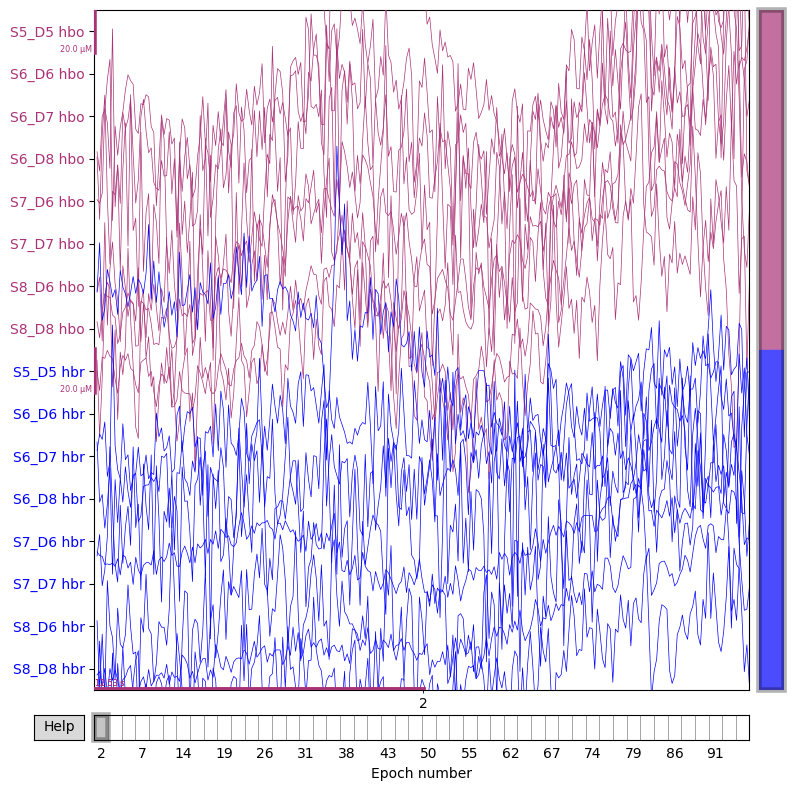

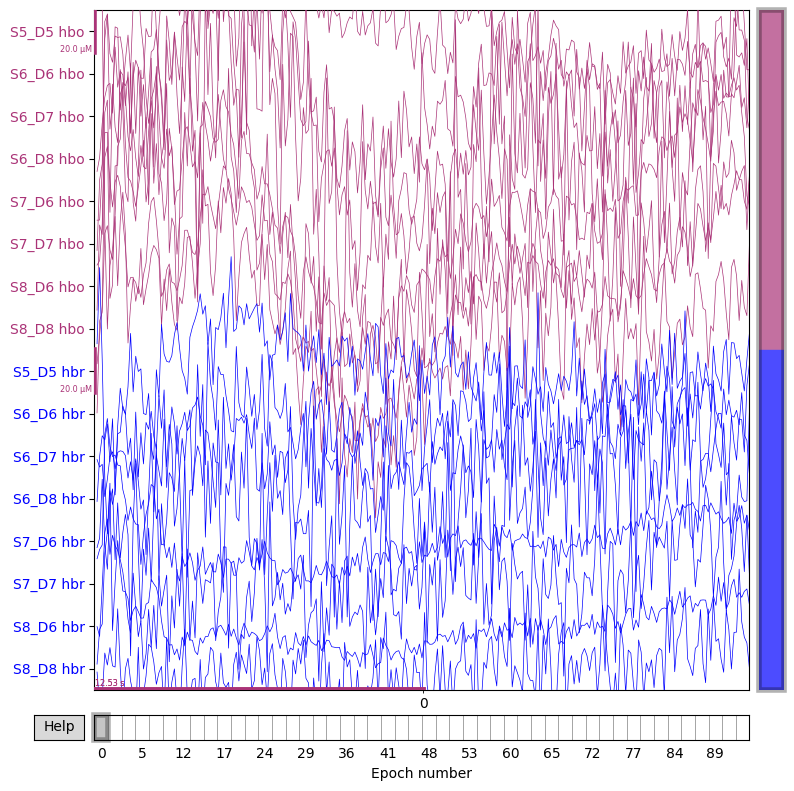

In [35]:

# Checking the outputs make sense for the epochs 
def validate_epochs(epochs, region_name):
    
    print(f"\n=== {region_name} Validation ===")

    print(f"  Scene epochs: {len(epochs['Scene'])}")
    print(f"  Rest epochs:  {len(epochs['Rest'])}")

    print(f"  Epoch duration: {epochs.tmax - epochs.tmin:.2f}s")
    print(f"  Samples per epoch: {len(epochs.times)}")

    print(f"\n  Epoch onsets (Scene): {epochs['Scene'].events[:, 0] / epochs.info['sfreq']}")
    print(f"  Epoch onsets (Rest):  {epochs['Rest'].events[:, 0] / epochs.info['sfreq']}")


    print(f"\n  Channels: {len(epochs.ch_names)}")
    print(f"  HbO channels: {len([c for c in epochs.ch_names if 'hbo' in c])}")
    print(f"  HbR channels: {len([c for c in epochs.ch_names if 'hbr' in c])}")

    data = epochs.get_data()
    print(f"\n  Any NaNs: {np.isnan(data).any()}")
    print(f"  Any flat channels (std=0): {(data.std(axis=-1) == 0).any()}")

    epochs['Scene'].plot(n_epochs=1, title=f"{region_name} - Scene")
    epochs['Rest'].plot(n_epochs=1,  title=f"{region_name} - Rest")

 

validate_epochs(epochs_frontal, "Frontal")
validate_epochs(epochs_posterior, "Posterior")

In [ ]:
# Create new epochs with only the last 5 seconds of each original epoch
def get_last_5_seconds(epochs, region_name):
    
    last_5_sec_epochs = epochs.copy().crop(tmin=-5.0, tmax=5)
    
    print(f"{region_name} — Last 5 seconds of each epoch: {len(last_5_sec_epochs)}")
    
    return last_5_sec_epochs

last5_frontal   = get_last_5_seconds(epochs_frontal,   "Frontal")
last5_posterior = get_last_5_seconds(epochs_posterior, "Posterior")


Frontal — Last 5 seconds of each epoch: 96
Posterior — Last 5 seconds of each epoch: 96


C:\Users\sasha\AppData\Local\Temp\ipykernel_11276\911990611.py:4: RuntimeWarning: tmin is not in time interval. tmin is set to <class 'mne.epochs.Epochs'>.tmin (5.0135 s)
  last_5_sec_epochs = epochs.copy().crop(tmin=-5.0, tmax=epochs.tmax)
C:\Users\sasha\AppData\Local\Temp\ipykernel_11276\911990611.py:4: RuntimeWarning: tmin is not in time interval. tmin is set to <class 'mne.epochs.Epochs'>.tmin (5.0135 s)
  last_5_sec_epochs = epochs.copy().crop(tmin=-5.0, tmax=epochs.tmax)


In [44]:
print(last5_frontal.tmin, last5_frontal.tmax)
print(len(last5_frontal.times))

5.013504 29.98272
255


C:\Users\sasha\AppData\Local\Temp\ipykernel_11276\2565937157.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


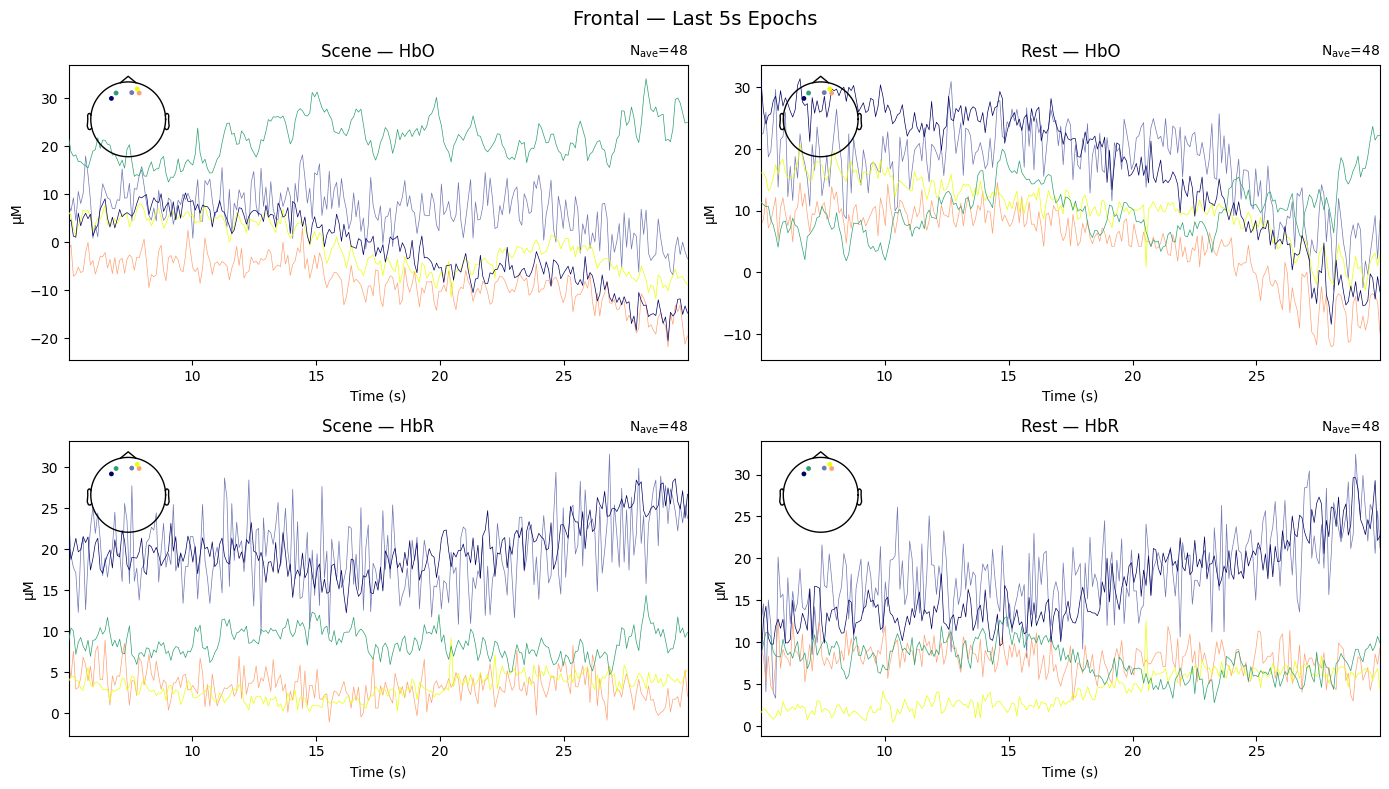

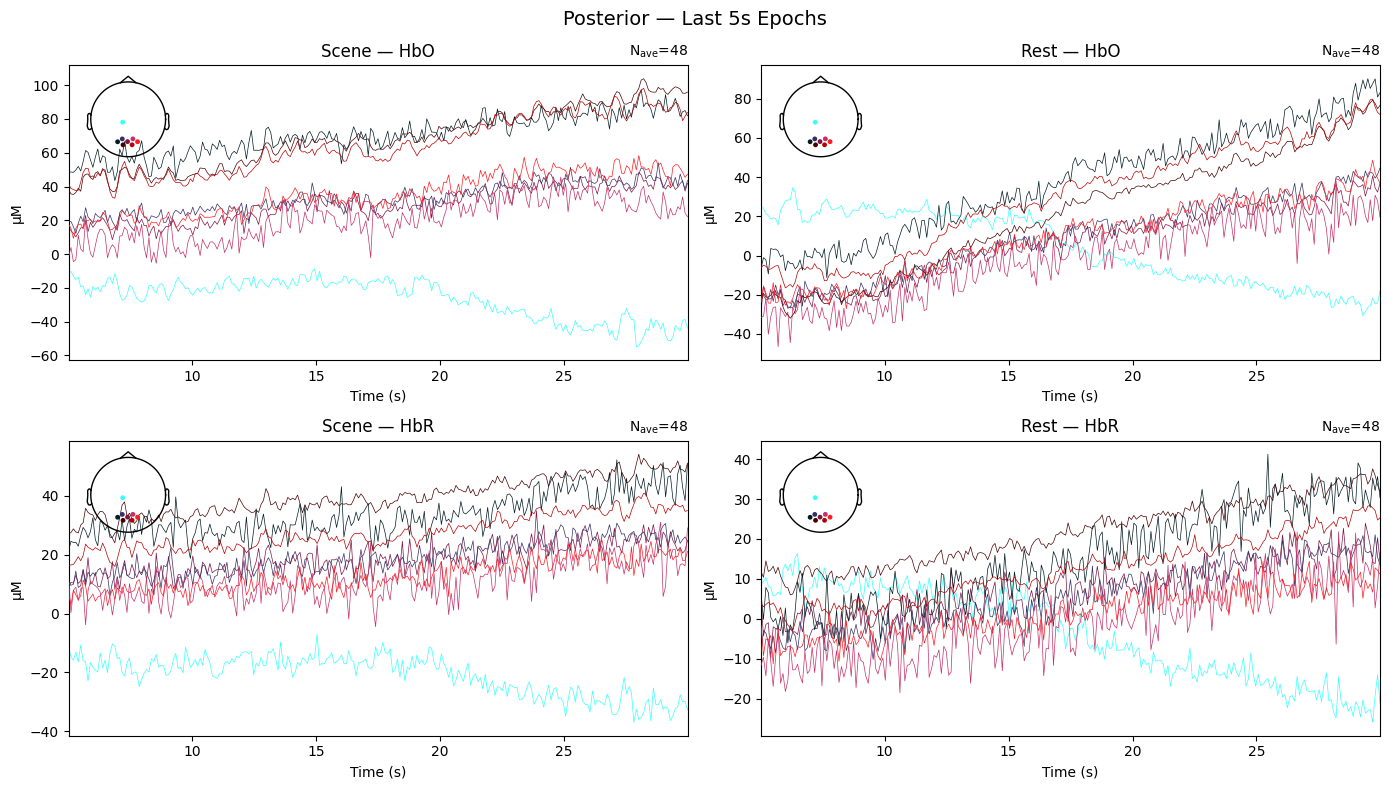

In [42]:
def plot_last5(last5, region_name):

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f"{region_name} — Last 5s Epochs", fontsize=14)

    last5['Scene'].average().pick("hbo").plot(axes=axes[0, 0], show=False)
    axes[0, 0].set_title("Scene — HbO")

    last5['Rest'].average().pick("hbo").plot(axes=axes[0, 1], show=False)
    axes[0, 1].set_title("Rest — HbO")

    last5['Scene'].average().pick("hbr").plot(axes=axes[1, 0], show=False)
    axes[1, 0].set_title("Scene — HbR")

    last5['Rest'].average().pick("hbr").plot(axes=axes[1, 1], show=False)
    axes[1, 1].set_title("Rest — HbR")

    plt.tight_layout()
    plt.show()


plot_last5(last5_frontal,   "Frontal")
plot_last5(last5_posterior, "Posterior")

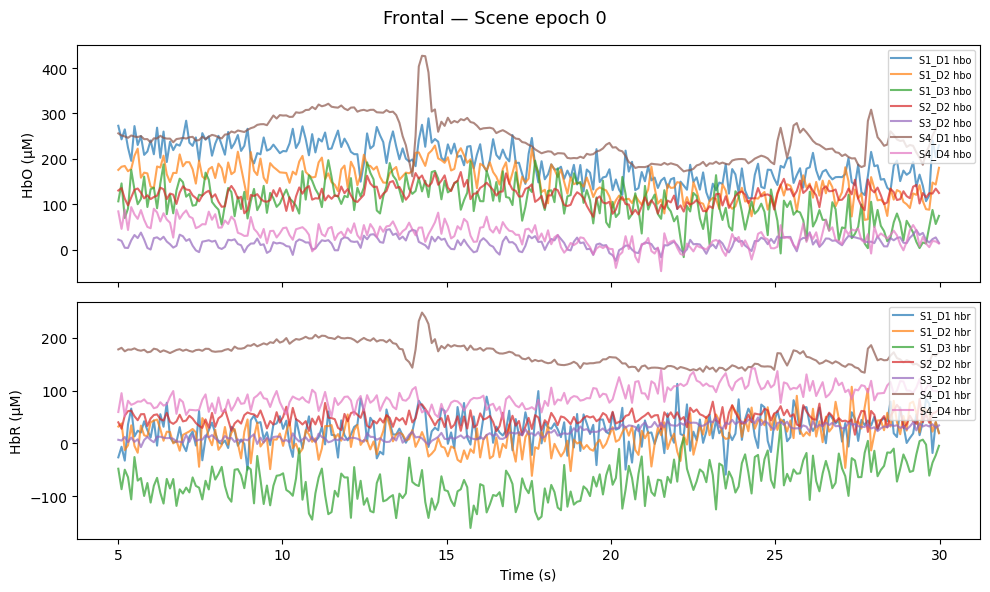

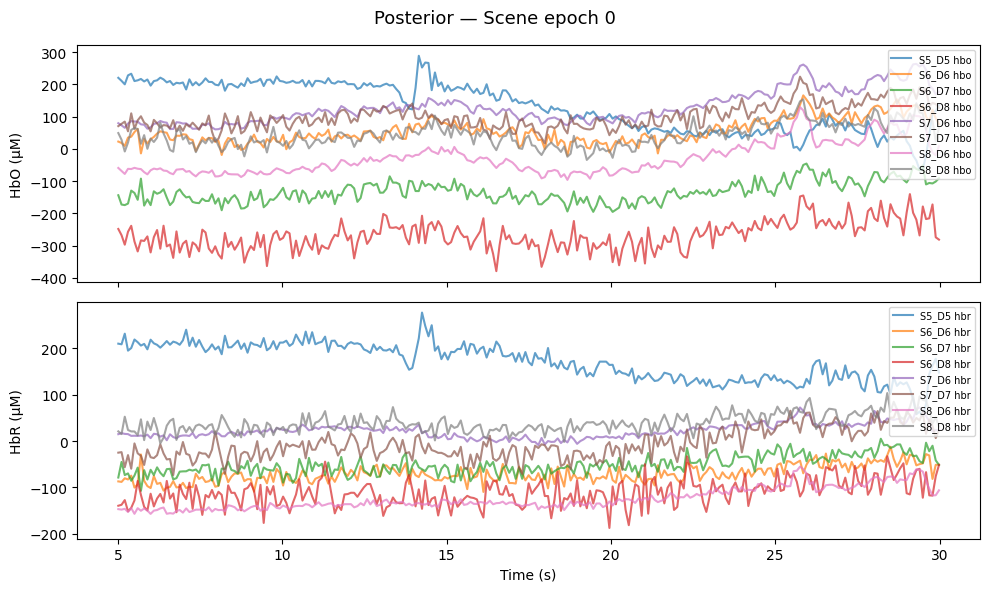

In [43]:
def plot_single_epoch(last5, region_name, condition="Scene", epoch_idx=0):

    # Get data for a single epoch: shape (n_channels, n_times)
    single = last5[condition][epoch_idx]
    data   = single.get_data()[0]  # (n_channels, n_times)
    times  = last5.times

    hbo_picks = [i for i, ch in enumerate(last5.ch_names) if "hbo" in ch]
    hbr_picks = [i for i, ch in enumerate(last5.ch_names) if "hbr" in ch]

    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    fig.suptitle(f"{region_name} — {condition} epoch {epoch_idx}", fontsize=13)

    # HbO
    for i in hbo_picks:
        axes[0].plot(times, data[i] * 1e6, alpha=0.7, label=last5.ch_names[i])
    axes[0].set_ylabel("HbO (μM)")
    axes[0].legend(fontsize=7, loc="upper right")

    # HbR
    for i in hbr_picks:
        axes[1].plot(times, data[i] * 1e6, alpha=0.7, label=last5.ch_names[i])
    axes[1].set_ylabel("HbR (μM)")
    axes[1].set_xlabel("Time (s)")
    axes[1].legend(fontsize=7, loc="upper right")

    plt.tight_layout()
    plt.show()


plot_single_epoch(last5_frontal,   "Frontal",   condition="Scene", epoch_idx=0)
plot_single_epoch(last5_posterior, "Posterior", condition="Scene", epoch_idx=0)